<a href="https://colab.research.google.com/github/aj6781700/Deep-learning/blob/main/CNN_Fundamentals_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device: GPU > Apple Silicon > CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('PyTorch:', torch.__version__)
print('Device :', DEVICE)


PyTorch: 2.10.0+cpu
Device : cpu


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device: GPU > Apple Silicon > CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('PyTorch:', torch.__version__)
print('Device :', DEVICE)

# ── 1a. Convolution by hand (pure NumPy) ────────────────────────────────

def conv2d_manual(image, kernel, stride=1, padding=0):
    H, W   = image.shape
    kH, kW = kernel.shape
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)
    H_pad, W_pad = image.shape
    out_H = (H_pad - kH) // stride + 1
    out_W = (W_pad - kW) // stride + 1
    fm = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            fm[i, j] = np.sum(patch * kernel)
    return fm

# A simple 5×5 image with a clear horizontal edge
img = np.array([
    [10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10],
    [ 0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0],
], dtype=float)

# Horizontal edge detector
kernel_edge = np.array([[ 1, 1, 1], [ 0, 0, 0], [-1,-1,-1]], dtype=float)

fm_no_pad = conv2d_manual(img, kernel_edge, stride=1, padding=0)
fm_padded = conv2d_manual(img, kernel_edge, stride=1, padding=1)

print("Input (5×5):")
print(img)
print("\nFeature map — no padding → output shape:", fm_no_pad.shape)
print(fm_no_pad)
print("\nFeature map — padding=1 → output shape:", fm_padded.shape)
print("High values = edge detected!")

PyTorch: 2.10.0+cpu
Device : cpu
Input (5×5):
[[10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]

Feature map — no padding → output shape: (3, 3)
[[30. 30. 30.]
 [30. 30. 30.]
 [ 0.  0.  0.]]

Feature map — padding=1 → output shape: (5, 5)
High values = edge detected!


In [ ]:
# ── 1b. Output size: how stride & padding affect dimensions ──────────────

def out_size(inp, k, s=1, p=0):
    return (inp - k + 2*p) // s + 1

configs = [
    (32, 3, 1, 0, "Standard conv, no padding"),
    (32, 3, 1, 1, "Standard conv, padding=1 (SAME)"),
    (32, 3, 2, 0, "Stride-2 conv  (downsamples)"),
    (32, 5, 1, 2, "5×5 kernel,   padding=2 (SAME)"),
]
print(f"{'Description':<32} Input  K  S  P  Output")
print("-" * 58)
for inp, k, s, p, desc in configs:
    print(f"  {desc:<30} {inp:>5}  {k}  {s}  {p}  → {out_size(inp,k,s,p)}")

print("\nKey rule: padding = (kernel - 1) // 2  gives SAME output size with stride=1")


Description                      Input  K  S  P  Output
----------------------------------------------------------
  Standard conv, no padding         32  3  1  0  → 30
  Standard conv, padding=1 (SAME)    32  3  1  1  → 32
  Stride-2 conv  (downsamples)      32  3  2  0  → 15
  5×5 kernel,   padding=2 (SAME)    32  5  1  2  → 32

Key rule: padding = (kernel - 1) // 2  gives SAME output size with stride=1


In [ ]:
conv = nn.Conv2d(
    in_channels  = 1,   # grayscale
    out_channels = 3,   # 3 kernels → 3 feature maps
    kernel_size  = 3,
    stride       = 1,
    padding      = 1,   # SAME padding
)

print("Weight shape:", conv.weight.shape)   # (out_ch, in_ch, kH, kW)
print("Parameters  :", conv.weight.numel() + conv.bias.numel())

x = torch.randn(1, 1, 28, 28)             # (batch, channels, H, W)
with torch.no_grad():
    y = conv(x)
print("\nInput  shape:", tuple(x.shape))
print("Output shape:", tuple(y.shape))
print("→ 3 kernels produced 3 feature maps; spatial size preserved by padding=1")

Weight shape: torch.Size([3, 1, 3, 3])
Parameters  : 30

Input  shape: (1, 1, 28, 28)
Output shape: (1, 3, 28, 28)
→ 3 kernels produced 3 feature maps; spatial size preserved by padding=1


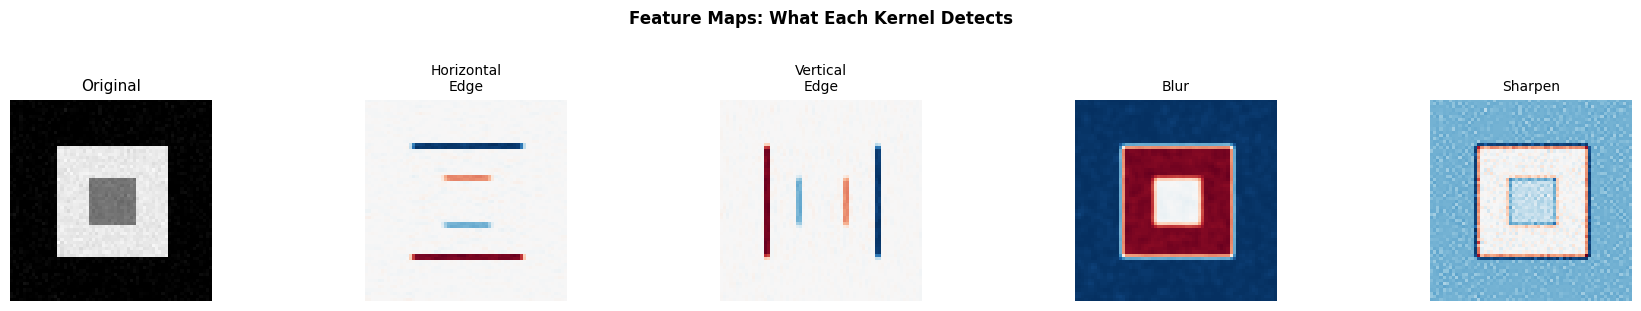

In [ ]:
# ── 2a. Visualise 4 hand-crafted kernels on a synthetic image ────────────

np.random.seed(42)
synthetic = np.zeros((64, 64))
synthetic[15:50, 15:50] = 200
synthetic[25:40, 25:40] = 100
synthetic += np.random.normal(0, 5, (64, 64))
synthetic = np.clip(synthetic, 0, 255)

kernels = {
    "Horizontal\nEdge": np.array([[ 1, 2, 1],[ 0, 0, 0],[-1,-2,-1]], dtype=float),
    "Vertical\nEdge":   np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]], dtype=float),
    "Blur":              np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=float) / 16,
    "Sharpen":           np.array([[ 0,-1, 0],[-1, 5,-1],[ 0,-1, 0]], dtype=float),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(synthetic, cmap='gray')
axes[0].set_title("Original", fontsize=11)
axes[0].axis('off')

for ax, (name, k) in zip(axes[1:], kernels.items()):
    fm = conv2d_manual(synthetic, k, stride=1, padding=1)
    ax.imshow(fm, cmap='RdBu_r')
    ax.set_title(name, fontsize=10)
    ax.axis('off')

plt.suptitle("Feature Maps: What Each Kernel Detects", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


####Q. **CV is Hard, How?**  
- Occlusion
><img src='https://drive.google.com/uc?id=1BEPnFwfEHbyS9B0mGuwH3PrXoSD3hD3p' height=350>
- Illumination variability
><img src='https://drive.google.com/uc?id=1lCwC1MQ3J8oLEI8wVUUASvEDezyvzxny' height=350>
- Pose Variability
><img src='https://drive.google.com/uc?id=1EomrGXii9kUWuFBAdvj97VnGY5Gs57JZ' height=350>


**Scope of CV is Enormous!**
- Computer vision is used in industry leading products like self-driving cars, automated robots, drones, medical image analysis, etc.
- Apart from this, CV is also used in conjunction with other fields of AI like Speech and NLP.
- For example, in the case of Speech Recognition, we first convert audio chunks to 2D matrices (called mel spectrogram) and treat it like images. In NLP, we use CV techniques for Image Captioning and very recently Image Synthesis from prompts.   

>*Note that the above image of dog is artificially generated using [Stable Diffusion](https://huggingface.co/spaces/stabilityai/stable-diffusion) model, with the following prompt: `A dog made of origami. Highly detailed. Photograph. 4k. Colorful`*


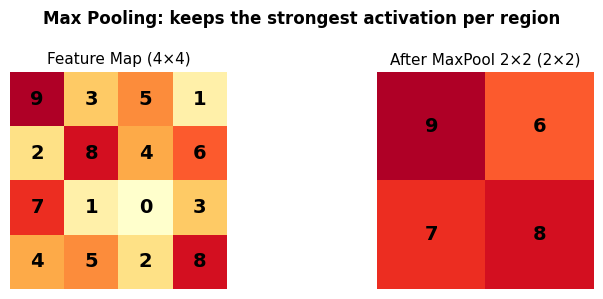

Top-left  window [9,3,2,8]  → max = 9
Top-right window [5,1,4,6]  → max = 6
Bot-left  window [7,1,4,5]  → max = 7
Bot-right window [0,3,2,8]  → max = 8


In [ ]:
# ── 2b. Max pooling by hand ──────────────────────────────────────────────

fm_4x4 = np.array([
    [ 9, 3, 5, 1],
    [ 2, 8, 4, 6],
    [ 7, 1, 0, 3],
    [ 4, 5, 2, 8],
], dtype=float)

def maxpool2d_manual(fm, pool=2, stride=2):
    H, W = fm.shape
    oH = (H - pool) // stride + 1
    oW = (W - pool) // stride + 1
    out = np.zeros((oH, oW))
    for i in range(oH):
        for j in range(oW):
            out[i, j] = fm[i*stride:i*stride+pool, j*stride:j*stride+pool].max()
    return out

pooled = maxpool2d_manual(fm_4x4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
for ax, data, title in [
    (ax1, fm_4x4, "Feature Map (4×4)"),
    (ax2, pooled,  "After MaxPool 2×2 (2×2)"),
]:
    ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=10)
    ax.set_title(title, fontsize=11)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, int(data[i,j]), ha='center', va='center',
                    fontsize=14, fontweight='bold')
    ax.axis('off')
plt.suptitle("Max Pooling: keeps the strongest activation per region", fontweight='bold')
plt.tight_layout()
plt.show()

print("Top-left  window [9,3,2,8]  → max = 9")
print("Top-right window [5,1,4,6]  → max = 6")
print("Bot-left  window [7,1,4,5]  → max = 7")
print("Bot-right window [0,3,2,8]  → max = 8")


In [ ]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1: 32×32 → 16×16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        # Block 2: 16×16 → 8×8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)   # raw logits — CrossEntropyLoss adds softmax


model = CIFAR10_CNN().to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")


Total parameters: 1,117,354


In [ ]:
# ── Trace tensor shapes through each layer (critical debugging tool) ──────

def trace_shapes(model, input_shape=(1, 3, 32, 32)):
    x = torch.zeros(*input_shape).to(DEVICE)
    print(f"Input: {tuple(x.shape)}")
    print("─" * 45)
    with torch.no_grad():
        for block_name in ['block1', 'block2', 'classifier']:
            block = getattr(model, block_name)
            for i, layer in enumerate(block):
                x = layer(x)
                print(f"  {block_name}[{i}] {type(layer).__name__:<16} → {tuple(x.shape)}")
    print("─" * 45)
    print(f"Output: {tuple(x.shape)}  ← 10 logits, one per class")

trace_shapes(model)


Input: (1, 3, 32, 32)
─────────────────────────────────────────────
  block1[0] Conv2d           → (1, 32, 32, 32)
  block1[1] BatchNorm2d      → (1, 32, 32, 32)
  block1[2] ReLU             → (1, 32, 32, 32)
  block1[3] Conv2d           → (1, 32, 32, 32)
  block1[4] BatchNorm2d      → (1, 32, 32, 32)
  block1[5] ReLU             → (1, 32, 32, 32)
  block1[6] MaxPool2d        → (1, 32, 16, 16)
  block1[7] Dropout2d        → (1, 32, 16, 16)
  block2[0] Conv2d           → (1, 64, 16, 16)
  block2[1] BatchNorm2d      → (1, 64, 16, 16)
  block2[2] ReLU             → (1, 64, 16, 16)
  block2[3] Conv2d           → (1, 64, 16, 16)
  block2[4] BatchNorm2d      → (1, 64, 16, 16)
  block2[5] ReLU             → (1, 64, 16, 16)
  block2[6] MaxPool2d        → (1, 64, 8, 8)
  block2[7] Dropout2d        → (1, 64, 8, 8)
  classifier[0] Flatten          → (1, 4096)
  classifier[1] Linear           → (1, 256)
  classifier[2] ReLU             → (1, 256)
  classifier[3] Dropout          → (1, 256)
  class

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),    # mirror 50% of the time
    transforms.RandomCrop(32, padding=4),       # shift up to 4 pixels then crop
    transforms.RandomRotation(degrees=15),      # rotate ±15°
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Load CIFAR-10
train_dataset = datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
val_dataset   = datasets.CIFAR10('./data', train=False, download=True, transform=val_transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f"Training images  : {len(train_dataset):,}")
print(f"Validation images: {len(val_dataset):,}")
print(f"Batches per epoch: {len(train_loader)}")


 10%|▉         | 16.3M/170M [04:51<1:06:38, 38.6kB/s]

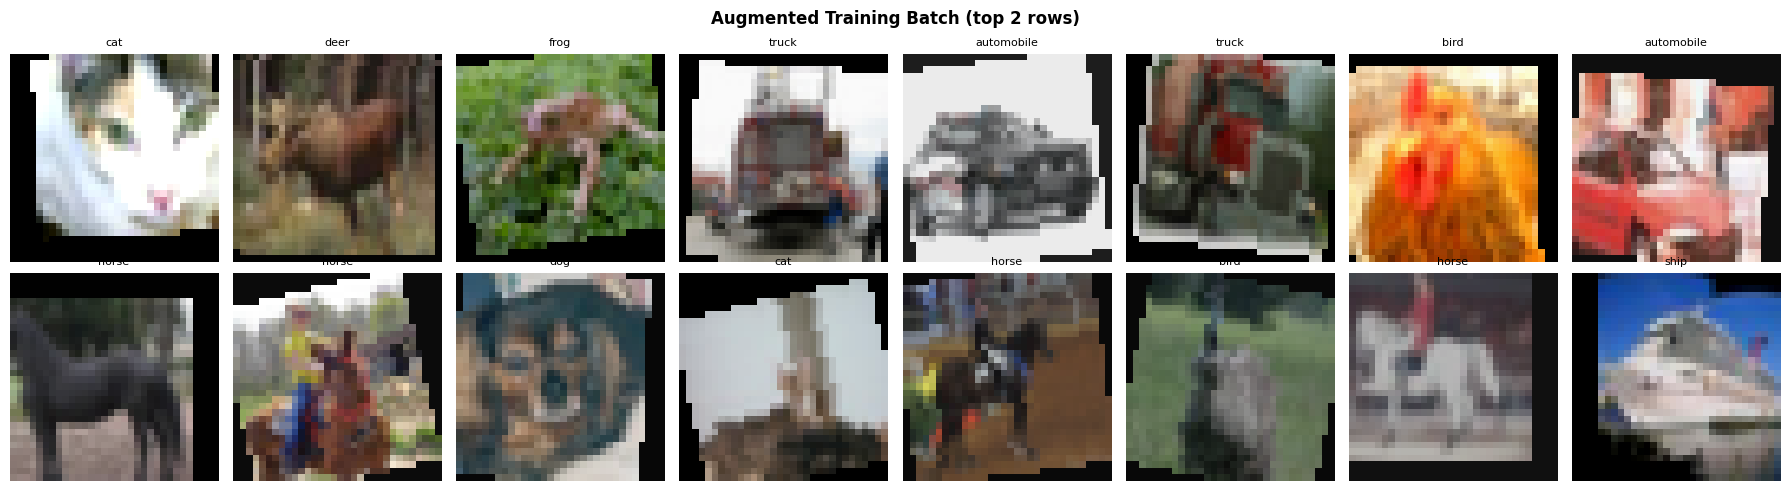

In [ ]:
# ── Visualise one batch ───────────────────────────────────────────────────

mean_t = torch.tensor(CIFAR10_MEAN).view(3,1,1)
std_t  = torch.tensor(CIFAR10_STD).view(3,1,1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle("Augmented Training Batch (top 2 rows)", fontsize=12, fontweight='bold')
for idx, ax in enumerate(axes.flatten()):
    img = (images[idx] * std_t + mean_t).permute(1,2,0).numpy().clip(0,1)
    ax.imshow(img)
    ax.set_title(CLASSES[labels[idx].item()], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def train_one_epoch(model, loader, criterion, optimiser, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * len(images)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += len(images)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * len(images)
            correct    += logits.argmax(1).eq(labels).sum().item()
            total      += len(images)
    return total_loss / total, correct / total


criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=3)

print("Loss     : CrossEntropyLoss")
print("Optimiser: Adam  (lr=1e-3)")
print("Scheduler: ReduceLROnPlateau")


Loss     : CrossEntropyLoss
Optimiser: Adam  (lr=1e-3)
Scheduler: ReduceLROnPlateau


In [ ]:
N_EPOCHS = 15   # Increase to 25–30 for stronger accuracy

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0.0

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print("─" * 55)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimiser, DEVICE)
    va_loss, va_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(va_loss)

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);    val_accs.append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"  {epoch:>3}  | {tr_loss:>10.4f} | {tr_acc*100:>8.1f}% | {va_loss:>8.4f} | {va_acc*100:>6.1f}%")

print(f"\nBest validation accuracy: {best_val_acc*100:.1f}%")


Epoch | Train Loss | Train Acc | Val Loss | Val Acc
───────────────────────────────────────────────────────
    1  |     1.8929 |     29.8% |   1.4765 |   46.2%
    2  |     1.6858 |     37.4% |   1.3408 |   50.5%
    3  |     1.5837 |     41.5% |   1.2667 |   53.4%
    4  |     1.5164 |     44.4% |   1.2187 |   55.1%
    5  |     1.4608 |     46.3% |   1.1565 |   58.5%
    6  |     1.4150 |     48.8% |   1.1355 |   59.0%
    7  |     1.3735 |     50.1% |   1.1192 |   60.6%
    8  |     1.3450 |     51.2% |   1.0175 |   62.3%
    9  |     1.3239 |     52.3% |   1.0394 |   62.9%
   10  |     1.2997 |     53.1% |   0.9492 |   65.6%
   11  |     1.2669 |     54.3% |   0.9584 |   65.4%
   12  |     1.2472 |     55.6% |   0.9664 |   65.0%
   13  |     1.2230 |     56.3% |   0.8752 |   68.4%
   14  |     1.2070 |     57.1% |   0.8619 |   69.3%
   15  |     1.1912 |     57.6% |   0.8714 |   69.0%

Best validation accuracy: 69.3%


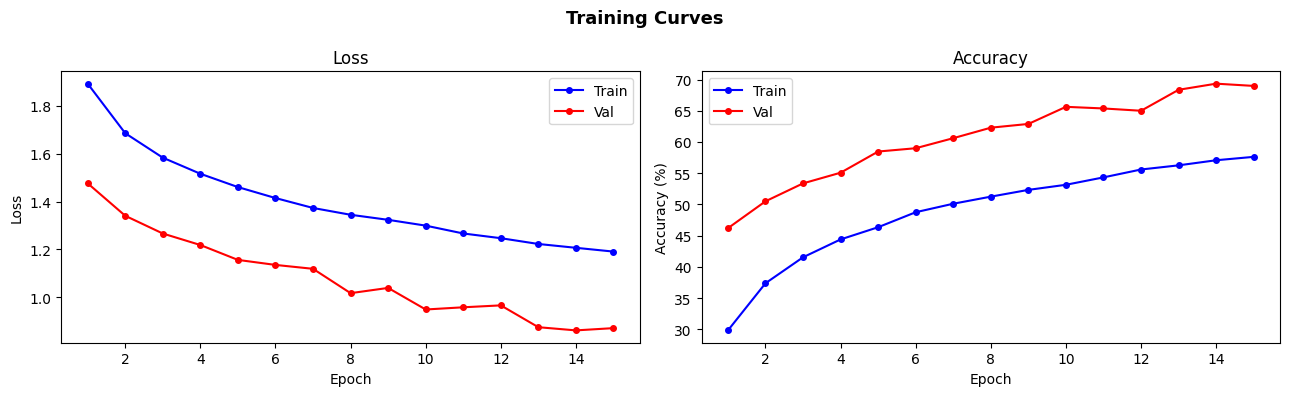

Train–Val gap: -11.4%
→ Looking healthy!


In [ ]:
# ── Training curves ───────────────────────────────────────────────────────

epochs = range(1, N_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, train_losses, 'b-o', ms=4, label='Train')
ax1.plot(epochs, val_losses,   'r-o', ms=4, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend()

ax2.plot(epochs, [a*100 for a in train_accs], 'b-o', ms=4, label='Train')
ax2.plot(epochs, [a*100 for a in val_accs],   'r-o', ms=4, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend()

plt.suptitle('Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

gap = (train_accs[-1] - val_accs[-1]) * 100
print(f"Train–Val gap: {gap:.1f}%")
if gap > 15:
    print("→ Overfitting. Try more dropout / augmentation.")
elif val_accs[-1] < 0.65:
    print("→ Underfitting. Train longer or add more capacity.")
else:
    print("→ Looking healthy!")


Final accuracy: 69.3%

              precision    recall  f1-score   support

    airplane       0.78      0.67      0.72      1000
  automobile       0.81      0.89      0.85      1000
        bird       0.61      0.47      0.53      1000
         cat       0.50      0.38      0.43      1000
        deer       0.74      0.55      0.63      1000
         dog       0.51      0.71      0.59      1000
        frog       0.64      0.84      0.73      1000
       horse       0.79      0.75      0.77      1000
        ship       0.83      0.82      0.83      1000
       truck       0.76      0.85      0.80      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



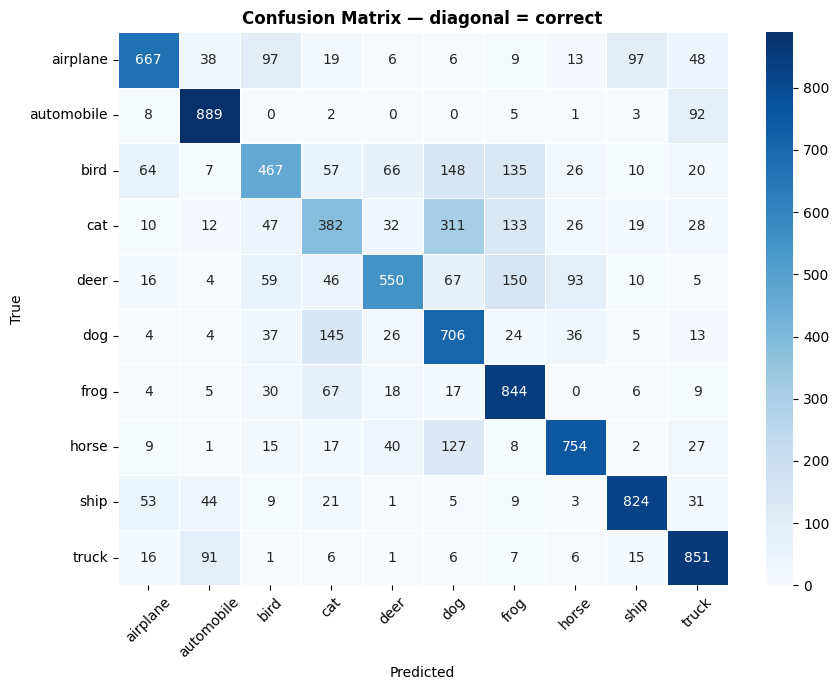

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────

model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"Final accuracy: {(all_preds==all_labels).mean()*100:.1f}%\n")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.4, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — diagonal = correct', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
